# Classificazione di `RainTomorrow`

L'EDA ha stabilito che il dataset **non è un insieme di osservazioni indipendenti**: è un panel
di serie storiche, 49 stazioni osservate giornalmente dal 2007 al 2017, con chiave
(`Location`, `Date`). Ne derivano due rischi distinti.

**1. Leakage diretto.** `RISK_MM` è la pioggia in mm del giorno successivo, cioè la grandezza da
cui `RainTomorrow` è derivata. Assente nella versione attuale del dataset, ma il notebook
verifica esplicitamente che non ci sia invece di scartarla in silenzio.

**2. Leakage temporale.** È il problema centrale.

**La soluzione adottata:** il training contiene i giorni **più vecchi**, il test quelli **più
recenti**, con taglio su una data di riferimento. Coerentemente, la cross-validation usa
`TimeSeriesSplit`, in tutti i punti in cui compare:
confronto dei modelli, grid search e calibrazione della soglia.

Tre passaggi sono necessari perché lo split funzioni davvero:

* **ordinare il file per data.** 
* **tagliare su una data e non su una posizione**
* **non usare `Date` come feature.** Serve solo a definire lo split.

Vengono rimosse solo le colonne che presentano valori mancanti, indicate in `SPARSE_DROP`.

In [41]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (TimeSeriesSplit, cross_val_score,
                                     GridSearchCV, train_test_split)
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.inspection import permutation_importance

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)

try:
    from MetaCost import MetaCost
    HAS_METACOST = True
except ImportError:
    HAS_METACOST = False
    print("MetaCost.py non trovato: la strategia MetaCost verra' saltata.")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [42]:
N_SAMPLE      = None    # righe usate (None = tutte)
N_SAMPLE_MC   = 15000   # sottocampione dedicato a MetaCost
N_STUDY       = 20000   # sottocampione per lo studio sullo sbilanciamento
CV_FOLDS      = 5       # fold di TimeSeriesSplit

TEST_FRACTION = 0.20    # quota finale di GIORNI riservata al test 
VAL_FRACTION  = 0.20    # quota finale del TRAIN usata per calibrare la soglia

# Embargo fra training e validazione di ogni fold della CV, in righe.
# Evita che le giornate a cavallo del confine, quasi duplicate, finiscano da entrambe le parti.
CV_GAP        = 500 # circa 10 giorni

# Colonne scartate per eccesso di mancanti 
SPARSE_DROP = ["Sunshine", "Cloud3pm", "Evaporation", "Cloud9am"]

REDUNDANT_DROP = []

# Matrice dei costi. C[i, j] = costo di predire i quando la verita' e' j.
#   C[0,1] = predire "No" quando piove       -> FALSO NEGATIVO (grave: pioggia mancata)
#   C[1,0] = predire "Si'" quando non piove  -> falso allarme (lieve)
COST_FN = 3
COST_FP = 1
COST_MATRIX = np.array([[0, COST_FN],
                        [COST_FP, 0]])

# Criterio di scelta della soglia di decisione:
#   "f1"   -> massimizza l'F1 (pesa allo stesso modo precision e recall)
#   "cost" -> minimizza il costo atteso, coerente con COST_MATRIX
THRESHOLD_CRITERION = "cost"

def expected_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return COST_FN * fn + COST_FP * fp

def cost_per_1000(y_true, y_pred):
    return expected_cost(y_true, y_pred) / len(y_true) * 1000


def proba_of(model, Xa):
    # Tutti i candidati espongono predict_proba (LinearSVC e' calibrato), quindi la soglia
    # vive su una scala assoluta [0,1], confrontabile fra modelli e fra fit diversi.
    return model.predict_proba(Xa)[:, 1]


print("Matrice dei costi:\n", COST_MATRIX)
print(f"Criterio per la soglia: '{THRESHOLD_CRITERION}'")

Matrice dei costi:
 [[0 3]
 [1 0]]
Criterio per la soglia: 'cost'


## Caricamento e controllo anti-leakage

In [43]:
def load_dataset(filename="weatherAUS.csv", cartella="dataset"):
    for base in [Path.cwd(), *Path.cwd().parents]:
        file = base / cartella / filename
        if file.exists():
            return file
    raise FileNotFoundError(
        f"'{cartella}/{filename}' non trovato. Scarica il dataset da Kaggle "
        f"e mettilo nella cartella '{cartella}/' nella root del progetto."
    )

DATA_PATH = load_dataset()
df = pd.read_csv(DATA_PATH, parse_dates=["Date"], na_values="NA")

LEAK_COLS = ["RISK_MM"]
leaks = [c for c in LEAK_COLS if c in df.columns]
if leaks:
    print(f"ATTENZIONE: rimosse colonne di leakage diretto: {leaks}")
    df = df.drop(columns=leaks)
else:
    print("Nessuna colonna di leakage diretto (RISK_MM) presente. OK.")

print(f"\nRighe e colonne: {df.shape}")
print(f"Periodo: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Localita': {df['Location'].nunique()}")

Nessuna colonna di leakage diretto (RISK_MM) presente. OK.

Righe e colonne: (145460, 23)
Periodo: 2007-11-01 -> 2017-06-25
Localita': 49


## Ordinamento cronologico e pulizia

In [44]:
print("Il file e' gia' ordinato per data?", df["Date"].is_monotonic_increasing)

prima = len(df)
df = df.dropna(subset=["RainTomorrow"])

# ORDINAMENTO CRONOLOGICO: passaggio indispensabile prima di qualsiasi split temporale
df = df.sort_values(["Date", "Location"], kind="mergesort").reset_index(drop=True)

if N_SAMPLE is not None and N_SAMPLE < len(df):
    # tail() e non sample(): il campionamento casuale romperebbe l'ordine temporale
    df = df.tail(N_SAMPLE).reset_index(drop=True)
    print(f"Sottocampione: ultime {N_SAMPLE:,} righe (le piu' recenti)")

print(f"\nRighe: {prima:,} -> {len(df):,} (rimosse {prima - len(df):,} senza RainTomorrow)")
print("Ordinato per data dopo il sort?", df["Date"].is_monotonic_increasing)
print(f"Prima riga: {df['Date'].iloc[0].date()} | Ultima riga: {df['Date'].iloc[-1].date()}")

Il file e' gia' ordinato per data? False

Righe: 145,460 -> 142,193 (rimosse 3,267 senza RainTomorrow)
Ordinato per data dopo il sort? True
Prima riga: 2007-11-01 | Ultima riga: 2017-06-25


## Definizione delle feature

`Date` viene esclusa dai predittori ma conservata a parte perchè serve a definire lo split
cronologico, non a essere passata al modello. La stagionalità è comunque catturata da
`Month`, trattato come variabile categorica.

In [45]:
df["Month"] = df["Date"].dt.month

# Mappatura delle binarie, resa rieseguibile: un secondo .map() trasformerebbe 0/1 in NaN.
for c in ["RainToday", "RainTomorrow"]:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].map({"No": 0, "Yes": 1})

if "Rainfall" in REDUNDANT_DROP:
    df["RainfallLog"] = np.log1p(df["Rainfall"])

CATEGORICAL_COLS = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm", "Month"]

# Date e' esclusa dalle feature: definisce lo split, non e' un predittore.
X = df.drop(columns=["RainTomorrow", "Date"] + SPARSE_DROP + REDUNDANT_DROP)
y = df["RainTomorrow"].astype(int)
dates = df["Date"]

categorical_cols = [c for c in CATEGORICAL_COLS if c in X.columns]
numeric_cols     = [c for c in X.columns if c not in categorical_cols]

assert "Date" not in X.columns, "Date non deve essere una feature"
assert not set(numeric_cols) & set(categorical_cols), "colonna in entrambe le liste"

print(f"Righe usate: {len(df):,}")
print(f"Numeriche ({len(numeric_cols)}): {numeric_cols}")
print(f"Categoriche ({len(categorical_cols)}): {categorical_cols}")

Righe usate: 142,193
Numeriche (13): ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday']
Categoriche (5): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'Month']


Nota su `Rainfall` e `RainToday`. `RainToday` vale `Yes` se
e solo se `Rainfall > 1 mm`: è una funzione deterministica dell'altra, con gli stessi valori
mancanti. Non è leakage, perché entrambe si riferiscono al giorno *t* mentre il target è il
giorno *t+1*, ma è ridondanza pura e contribuisce ai VIF elevati misurati nell'EDA.


## Split cronologico train / test

In [46]:
cutoff = dates.iloc[int(len(df) * (1 - TEST_FRACTION))]

train_mask = dates <  cutoff
test_mask  = dates >= cutoff

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
dates_train, dates_test = dates[train_mask], dates[test_mask]

print(f"Data di taglio: {cutoff.date()}\n")
print(f"Train: {X_train.shape[0]:>7,} righe | {dates_train.min().date()} -> {dates_train.max().date()}")
print(f"Test : {X_test.shape[0]:>7,} righe | {dates_test.min().date()} -> {dates_test.max().date()}")
print(f"\nPioggia nel train: {y_train.mean():.2%} | nel test: {y_test.mean():.2%}")

# controlli sullo split
assert dates_train.max() < dates_test.min(), "sovrapposizione temporale fra train e test"
assert len(X_train) + len(X_test) == len(X), "righe perse nello split"
solo_test = set(X_test["Location"]) - set(X_train["Location"])
assert len(solo_test) == 0, f"localita' presenti solo nel test: {solo_test}"
print("\nControlli superati: nessuna sovrapposizione temporale, "
      "nessuna localita' esclusiva del test.")

Data di taglio: 2015-11-10

Train: 113,748 righe | 2007-11-01 -> 2015-11-09
Test :  28,445 righe | 2015-11-10 -> 2017-06-25

Pioggia nel train: 22.44% | nel test: 22.32%

Controlli superati: nessuna sovrapposizione temporale, nessuna localita' esclusiva del test.


## Preprocessing

Tutte le trasformazioni sono incapsulate in una `Pipeline`, così `cross_val_score` e
`GridSearchCV` le rifittano **dentro ogni fold**: mediane, medie e varianze dello scaler sono
calcolate solo sulla porzione di training di quel fold, mai sui dati di validazione.

`add_indicator=True` aggiunge una colonna binaria per ogni variabile numerica con mancanti nel
training. L'EDA ha mostrato che la mancanza è strutturale, legata alla strumentazione della
stazione: senza indicatore, dopo l'imputazione una misura reale pari alla mediana e un dato
assente diventerebbero indistinguibili.

In [47]:
preprocessor = ColumnTransformer([
    # Numeriche: imputazione con la mediana (piu' robusta della media su code pesanti),
    # indicatore di mancanza, standardizzazione.
    ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                      ("sc",  StandardScaler())]), numeric_cols),
    # Categoriche: imputazione con la moda e one-hot. handle_unknown="ignore" evita
    # errori su categorie mai viste in training.
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh",  OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
])

pre_check = clone(preprocessor).fit(X_train)
nomi = pre_check.get_feature_names_out()
n_ind = sum("missingindicator" in n for n in nomi)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Feature dopo il preprocessing: {len(nomi)}")
print(f"  di cui {len(numeric_cols)} numeriche scalate, {n_ind} indicatori di mancanza, "
      f"{len(nomi) - len(numeric_cols) - n_ind} dummy categoriche")

Train: (113748, 18) | Test: (28445, 18)
Feature dopo il preprocessing: 135
  di cui 13 numeriche scalate, 13 indicatori di mancanza, 109 dummy categoriche


## Sbilanciamento del target

Train -> No pioggia: 88,220 (77.6%) | Pioggia: 25,528 (22.4%)
Rapporto di sbilanciamento: 3.46 : 1


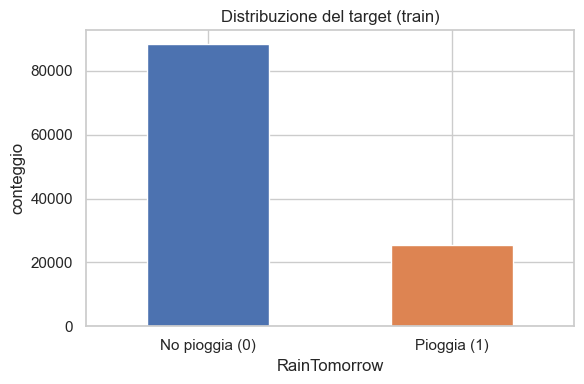

In [48]:
# Frequenza delle classi nel target di addestramento
dist = y_train.value_counts().sort_index()
# Rapporto tra casi negativi e positivi -> scale_pos_weight per XGBoost
ratio = dist[0] / dist[1]
print(f"Train -> No pioggia: {dist[0]:,} ({dist[0]/len(y_train):.1%}) | "
      f"Pioggia: {dist[1]:,} ({dist[1]/len(y_train):.1%})")
print(f"Rapporto di sbilanciamento: {ratio:.2f} : 1")

ax = dist.plot(kind="bar", color=["#4C72B0", "#DD8452"], figsize=(6, 4))
ax.set_xticklabels(["No pioggia (0)", "Pioggia (1)"], rotation=0)
ax.set_title("Distribuzione del target (train)"); ax.set_ylabel("conteggio")
plt.tight_layout()
plt.show()

## Baseline di riferimento

Due baseline:

* **maggioranza** — Predice sempre "no pioggia". Ha accuracy più alta ed F1 nullo sulla classe
  positiva;
* **persistenza** — Predice pioggia se è piovuto oggi. È la baseline
  che i meteorologi usano da sempre. 

In [ ]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

# Persistenza. I mancanti vengono associati a "no pioggia".
pred_pers = df.loc[test_mask, "RainToday"].fillna(0).astype(int).values

baseline = []
for nome, pred in [("Maggioranza", pred_dummy), ("Persistenza", pred_pers)]:
    baseline.append({"baseline": nome,
                     "accuracy": (pred == y_test.values).mean(),
                     "F1":       f1_score(y_test, pred),
                     "recall":   recall_score(y_test, pred),
                     "costo/1k": cost_per_1000(y_test, pred)})
pd.DataFrame(baseline).set_index("baseline").round(4)

,accuracy,F1,recall,costo/1k
baseline,,,,
Maggioranza,0.7768,0.0000,0.0000,669.6080
Persistenza,0.7532,0.4435,0.4405,496.5372


## Confronto dei modelli in cross-validation temporale

Con `TimeSeriesSplit` ogni fold addestra sui giorni
precedenti e valida su quelli immediatamente successivi, replicando la condizione operativa
reale. Il parametro `gap` inserisce l'embargo descritto nella sezione 1.

`LinearSVC` non espone `predict_proba` e da solo costringerebbe a normalizzare
`decision_function` con min e max, una scala fragile perché dipende dai valori estremi e non
confrontabile fra un fit e l'altro. Incapsulandolo in `CalibratedClassifierCV` tutti i candidati
restituiscono probabilità in [0, 1] e la soglia della sezione sulla calibrazione vive su una scala assoluta. La
CV interna del calibratore è a sua volta temporale, per non reintrodurre leakage dentro il fold.

Lo sbilanciamento è gestito a livello di modello con `class_weight` e `scale_pos_weight`; le
tecniche di resampling sono confrontate separatamente nella sezione successiva.

In [50]:
cv  = TimeSeriesSplit(n_splits=CV_FOLDS, gap=CV_GAP)
spw = float(ratio)

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Linear SVM":          CalibratedClassifierCV(
                               LinearSVC(random_state=RANDOM_STATE),
                               cv=TimeSeriesSplit(3), method="sigmoid"),
    "Random Forest":       RandomForestClassifier(n_estimators=150, n_jobs=-1,
                                                  random_state=RANDOM_STATE),
    "XGBoost":             XGBClassifier(n_estimators=150, learning_rate=0.1, n_jobs=-1,
                                         scale_pos_weight=1.0, eval_metric="logloss",
                                         random_state=RANDOM_STATE),
}

cv_results, cv_std = {}, {}
for name, clf in candidates.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", clf)])
    t = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                         scoring="average_precision", n_jobs=1)
    cv_results[name] = scores.mean()
    cv_std[name]     = scores.std()
    print(f"{name:22s} F1 = {scores.mean():.4f} (+/- {scores.std():.4f})   [{time.time()-t:.0f}s]")


best_name = max(cv_results, key=cv_results.get)
print(f"\nMigliore in CV temporale: {best_name}  (F1 = {cv_results[best_name]:.4f})")

Logistic Regression    F1 = 0.6996 (+/- 0.0148)   [6s]
Linear SVM             F1 = 0.6931 (+/- 0.0170)   [13s]
Random Forest          F1 = 0.7109 (+/- 0.0142)   [183s]
XGBoost                F1 = 0.7311 (+/- 0.0116)   [6s]

Migliore in CV temporale: XGBoost  (F1 = 0.7311)


## Studio delle tecniche per lo sbilanciamento

Il confronto avviene su un sottocampione, per contenere il costo di `NearMiss` che è
O(n_maggioritaria × n_minoritaria). Anche qui la suddivisione è **temporale**, ovvero si prendono le
ultime `N_STUDY` righe del training set e si taglia il 75/25 in ordine cronologico.

Il preprocessing è fittato solo sul sotto-train e applicato in `transform` alla validazione.
SMOTE e NearMiss lavorano esclusivamente sul sotto-train. La validazione conserva la
distribuzione originale, altrimenti i punti sintetici finirebbero a cavallo dei due insiemi.

Alla tabella è aggiunto il **costo atteso** con la matrice dei costi definita inizialmente, così il
confronto tiene conto dell'asimmetria fra pioggia mancata e falso allarme.

In [51]:
X_study = X_train.tail(N_STUDY)
y_study = y_train.tail(N_STUDY)

split_pos = int(len(X_study) * 0.75)
Xtr2, Xval = X_study.iloc[:split_pos], X_study.iloc[split_pos:]
ytr2, yval = y_study.iloc[:split_pos], y_study.iloc[split_pos:]

pre_study = clone(preprocessor).fit(Xtr2)
Xtr2_p = pre_study.transform(Xtr2); Xval_p = pre_study.transform(Xval)
Xtr2_d = Xtr2_p.toarray() if hasattr(Xtr2_p, "toarray") else Xtr2_p
Xval_d = Xval_p.toarray() if hasattr(Xval_p, "toarray") else Xval_p

print(f"Sotto-train: {Xtr2_d.shape[0]:,} righe | validazione: {Xval_d.shape[0]:,} righe")

def evaluate(model, Xv, yv, name):
    pred = model.predict(Xv)
    row = {"strategia": name,
           "F1":        f1_score(yv, pred),
           "precision": precision_score(yv, pred),
           "recall":    recall_score(yv, pred),
           "costo/1k":  cost_per_1000(yv, pred)}
    print(f"{name:26s} F1={row['F1']:.3f}  P={row['precision']:.3f}  "
          f"R={row['recall']:.3f}  costo/1k={row['costo/1k']:.0f}")
    return row

results = []
# 1 baseline (nessuna gestione dello sbilanciamento)
results.append(evaluate(LogisticRegression(max_iter=2000).fit(Xtr2_d, ytr2),
                        Xval_d, yval, "Baseline"))
# 2 class_weight
results.append(evaluate(LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr2_d, ytr2),
                        Xval_d, yval, "class_weight"))
# 3 SMOTE
Xs, ys = SMOTE(random_state=RANDOM_STATE).fit_resample(Xtr2_d, ytr2)
results.append(evaluate(LogisticRegression(max_iter=2000).fit(Xs, ys),
                        Xval_d, yval, "SMOTE"))
# 4 NearMiss + SMOTE
Xu, yu   = NearMiss(version=2).fit_resample(Xtr2_d, ytr2)
Xus, yus = SMOTE(random_state=RANDOM_STATE).fit_resample(Xu, yu)
results.append(evaluate(LogisticRegression(max_iter=2000).fit(Xus, yus),
                        Xval_d, yval, "NearMiss+SMOTE"))
# 5 LDA + class_weight (fit_transform sul sotto-train, transform sulla validazione)
lda = LinearDiscriminantAnalysis()
Xtr2_l = lda.fit_transform(Xtr2_d, ytr2); Xval_l = lda.transform(Xval_d)
results.append(evaluate(LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr2_l, ytr2),
                        Xval_l, yval, "LDA + class_weight"))

Sotto-train: 15,000 righe | validazione: 5,000 righe
Baseline                   F1=0.498  P=0.746  R=0.374  costo/1k=395
class_weight               F1=0.573  P=0.526  R=0.630  costo/1k=330
SMOTE                      F1=0.575  P=0.533  R=0.623  costo/1k=330
NearMiss+SMOTE             F1=0.511  P=0.400  R=0.708  costo/1k=382
LDA + class_weight         F1=0.562  P=0.504  R=0.634  costo/1k=339


In [ ]:
# 6 MetaCost (su sottocampione)
if HAS_METACOST:
    def run_metacost(Xtr_d, ytr_arr, Xv_d, yv, base_model, Cmat, title, m=8, n_sub=N_SAMPLE_MC):
        n_sub = min(n_sub, len(Xtr_d))
        S = pd.DataFrame(Xtr_d[:n_sub], columns=[f"f{i}" for i in range(Xtr_d.shape[1])])
        S["RainTomorrow"] = np.asarray(ytr_arr)[:n_sub]
        mc = MetaCost(S=S, L=base_model, C=Cmat, m=m, p=True, random_state=RANDOM_STATE)
        return evaluate(mc.fit("RainTomorrow", 2), Xv_d, yv, title)

    results.append(run_metacost(Xtr2_d, ytr2.values, Xval_d, yval,
                                LogisticRegression(max_iter=2000), COST_MATRIX, "MetaCost (LR)"))
    results.append(run_metacost(Xtr2_l, ytr2.values, Xval_l, yval,
                                LogisticRegression(max_iter=2000), COST_MATRIX, "MetaCost + LDA"))
else:
    print("MetaCost non disponibile: strategia saltata.")


study = pd.DataFrame(results).set_index("strategia").round(3)
print(f"\n=== Riepilogo strategie (validazione temporale) ===")
print(f"Miglior F1          : {study['F1'].idxmax()}")
print(f"Costo atteso minimo : {study['costo/1k'].idxmin()}")
study

MetaCost (LR)              F1=0.574  P=0.562  R=0.586  costo/1k=335
MetaCost + LDA             F1=0.565  P=0.539  R=0.594  costo/1k=340

=== Riepilogo strategie (validazione temporale) ===
Miglior F1          : SMOTE
Costo atteso minimo : SMOTE


,F1,precision,recall,costo/1k
strategia,,,,
Baseline,0.498,0.746,0.374,395.2
class_weight,0.573,0.526,0.630,330.4
SMOTE,0.575,0.533,0.623,330.2
NearMiss+SMOTE,0.511,0.400,0.708,382.0
LDA + class_weight,0.562,0.504,0.634,339.2
MetaCost (LR),0.574,0.562,0.586,334.6
MetaCost + LDA,0.565,0.539,0.594,340.0


**Lettura del risultato.** Se la gestione a livello di modello (`class_weight`) risulta
competitiva con il resampling, il modello finale la mantiene senza applicare SMOTE: stesse
prestazioni, molto meno costo computazionale e nessun dato sintetico. Questa sezione non è
quindi un'analisi a sé stante ma motiva la configurazione usata nelle sezioni successive.

## Ottimizzazione degli iperparametri

La grid search usa lo **stesso** oggetto `cv` temporale definito nelle sezioni precedenti.

In [53]:
param_grids = {
    "Logistic Regression": {"clf__C": [0.1, 1.0, 3.0]},
    # doppio prefisso: C sta nell'estimatore interno al calibratore
    "Linear SVM":          {"clf__estimator__C": [0.1, 1.0, 3.0]},
    "Random Forest":       {"clf__max_depth": [None, 20], "clf__min_samples_leaf": [1, 5]},
    "XGBoost":          {"clf__max_depth":        [4, 6, 8],
                            "clf__learning_rate":    [0.05, 0.1],
                            "clf__min_child_weight": [1, 5],
                            "clf__subsample":        [0.8, 1.0]},
}

grid_pipe = Pipeline([("pre", preprocessor), ("clf", candidates[best_name])])
gs = GridSearchCV(grid_pipe, param_grids[best_name],
                  scoring="average_precision", cv=cv, n_jobs=1)
gs.fit(X_train, y_train)

print(f"Migliori parametri: {gs.best_params_}")
print(f"F1 (CV temporale) ottimizzato: {gs.best_score_:.4f}")
best_model = clone(gs.best_estimator_)

Migliori parametri: {'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__min_child_weight': 5, 'clf__subsample': 0.8}
F1 (CV temporale) ottimizzato: 0.7340


## Calibrazione della soglia di decisione

 Con `TimeSeriesSplit` non si usa `cross_val_predict` perchè solleverebbe un errore in quanto la funzione richiede che ogni riga
compaia esattamente una volta come validazione, mentre in uno split temporale le righe iniziali
servono solo da training e non finiscono mai in un fold di validazione.

Si ritaglia quindi una **finestra di validazione temporale** dalla coda del training set: il
modello viene addestrato sulla parte precedente e la soglia scelta su quella finestra. Nella
sezione 13 il modello viene poi riaddestrato su tutto il training. Il test set non viene mai
toccato.

Sono calcolate entrambe le curve, F1 e costo atteso. Il criterio effettivo è deciso da
`THRESHOLD_CRITERION`, ovvero che un falso negativo costa cinque
volte un falso allarme, `"cost"` è la scelta coerente con quella premessa, mentre `"f1"`
riproduce il comportamento standard.

Fit soglia  :  90,999 righe | fino al 2014-07-17
Validazione :  22,749 righe | dal 2014-07-17 al 2015-11-09

Soglia max-F1    : 0.300  (F1 = 0.6422)
Soglia min-costo : 0.200  (costo/1k = 286)
Soglia adottata  : 0.200  (criterio 'cost')


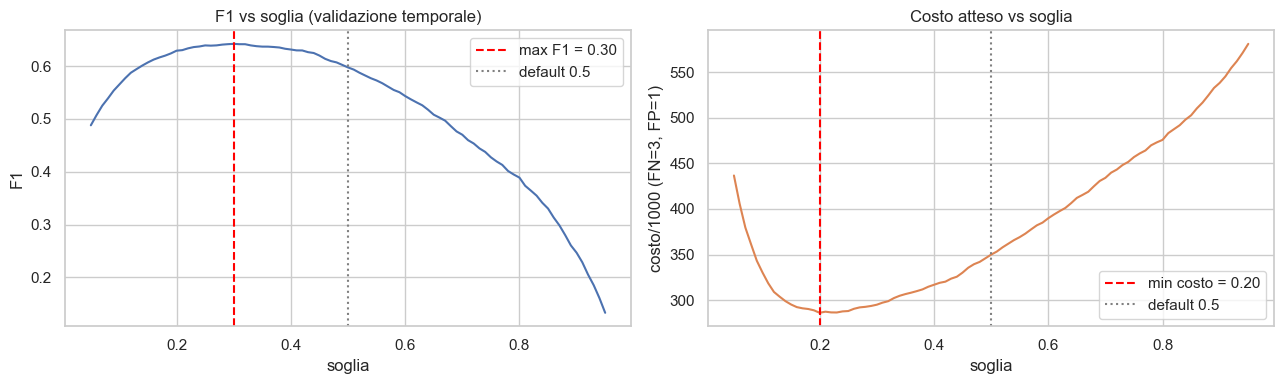

Soglie per fold: [0.22 0.23 0.25 0.27 0.21]
Mediana adottata: 0.230  (dispersione: 0.022)


In [ ]:
n_val  = int(len(X_train) * VAL_FRACTION)
X_fit, X_val_t = X_train.iloc[:-n_val], X_train.iloc[-n_val:]
y_fit, y_val_t = y_train.iloc[:-n_val], y_train.iloc[-n_val:]

print(f"Fit soglia  : {len(X_fit):>7,} righe | fino al {dates_train.iloc[-n_val-1].date()}")
print(f"Validazione : {len(X_val_t):>7,} righe | dal {dates_train.iloc[-n_val].date()} "
      f"al {dates_train.iloc[-1].date()}")

thr_model = clone(best_model).fit(X_fit, y_fit)

proba_val = proba_of(thr_model, X_val_t)

thresholds = np.linspace(0.05, 0.95, 91)
f1s   = [f1_score(y_val_t, (proba_val >= t).astype(int)) for t in thresholds]
costs = [cost_per_1000(y_val_t, (proba_val >= t).astype(int)) for t in thresholds]

t_f1   = thresholds[int(np.argmax(f1s))]
t_cost = thresholds[int(np.argmin(costs))]
best_t = t_cost if THRESHOLD_CRITERION == "cost" else t_f1

print(f"\nSoglia max-F1    : {t_f1:.3f}  (F1 = {max(f1s):.4f})")
print(f"Soglia min-costo : {t_cost:.3f}  (costo/1k = {min(costs):.0f})")
print(f"Soglia adottata  : {best_t:.3f}  (criterio '{THRESHOLD_CRITERION}')")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(thresholds, f1s)
ax[0].axvline(t_f1, ls="--", color="red", label=f"max F1 = {t_f1:.2f}")
ax[0].axvline(0.5, ls=":", color="gray", label="default 0.5")
ax[0].set_xlabel("soglia"); ax[0].set_ylabel("F1")
ax[0].set_title("F1 vs soglia (validazione temporale)"); ax[0].legend()

ax[1].plot(thresholds, costs, color="#DD8452")
ax[1].axvline(t_cost, ls="--", color="red", label=f"min costo = {t_cost:.2f}")
ax[1].axvline(0.5, ls=":", color="gray", label="default 0.5")
ax[1].set_xlabel("soglia"); ax[1].set_ylabel(f"costo/1000 (FN={COST_FN}, FP={COST_FP})")
ax[1].set_title("Costo atteso vs soglia"); ax[1].legend()
plt.tight_layout(); plt.show()


# Soglia robusta: calibrata su tutti i fold di TimeSeriesSplit invece che su una sola
# finestra. Una singola finestra di validazione produce soglie instabili.
soglie_fold = []
for tr_idx, va_idx in cv.split(X_train):
    m_f = clone(best_model).fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    p_f = proba_of(m_f, X_train.iloc[va_idx])
    y_f = y_train.iloc[va_idx]
    if THRESHOLD_CRITERION == "cost":
        crit = [cost_per_1000(y_f, (p_f >= t).astype(int)) for t in thresholds]
        soglie_fold.append(thresholds[int(np.argmin(crit))])
    else:
        crit = [f1_score(y_f, (p_f >= t).astype(int)) for t in thresholds]
        soglie_fold.append(thresholds[int(np.argmax(crit))])

best_t = float(np.median(soglie_fold))
soglia_std = float(np.std(soglie_fold))
print(f"Soglie per fold: {np.round(soglie_fold, 3)}")
print(f"Mediana adottata: {best_t:.3f}  (dispersione: {soglia_std:.3f})")

## Valutazione finale sul test set

Il modello viene riaddestrato su **tutto** il training set con gli iperparametri scelti e
applicato al test set con la soglia calibrata.

In [55]:
best_model.fit(X_train, y_train)
proba_test = proba_of(best_model, X_test)
y_pred = (proba_test >= best_t).astype(int)

print(f"=== {best_name} + soglia {best_t:.3f} — TEST SET "
      f"({dates_test.min().date()} -> {dates_test.max().date()}) ===\n")
print(classification_report(y_test, y_pred, target_names=["No pioggia", "Pioggia"]))
print(f"ROC-AUC        : {roc_auc_score(y_test, proba_test):.4f}")
print(f"PR-AUC         : {average_precision_score(y_test, proba_test):.4f}")
print(f"Costo per 1000 : {cost_per_1000(y_test, y_pred):.0f} (FN={COST_FN}, FP={COST_FP})")

# Confronto con la soglia di default, per quantificare il guadagno della calibrazione
y_pred_05 = (proba_test >= 0.5).astype(int)
confronto_soglia = pd.DataFrame([
    {"soglia": "0.50 (default)", "F1": f1_score(y_test, y_pred_05),
     "recall": recall_score(y_test, y_pred_05), "costo/1k": cost_per_1000(y_test, y_pred_05)},
    {"soglia": f"{best_t:.2f} (calibrata)", "F1": f1_score(y_test, y_pred),
     "recall": recall_score(y_test, y_pred), "costo/1k": cost_per_1000(y_test, y_pred)},
]).set_index("soglia").round(4)
print()
print(confronto_soglia.to_string())

=== XGBoost + soglia 0.230 — TEST SET (2015-11-10 -> 2017-06-25) ===

              precision    recall  f1-score   support

  No pioggia       0.93      0.82      0.87     22096
     Pioggia       0.56      0.78      0.65      6349

    accuracy                           0.81     28445
   macro avg       0.74      0.80      0.76     28445
weighted avg       0.85      0.81      0.82     28445

ROC-AUC        : 0.8840
PR-AUC         : 0.7325
Costo per 1000 : 286 (FN=3, FP=1)

                      F1  recall  costo/1k
soglia                                    
0.50 (default)    0.6278  0.5448  347.3721
0.23 (calibrata)  0.6497  0.7793  286.0608


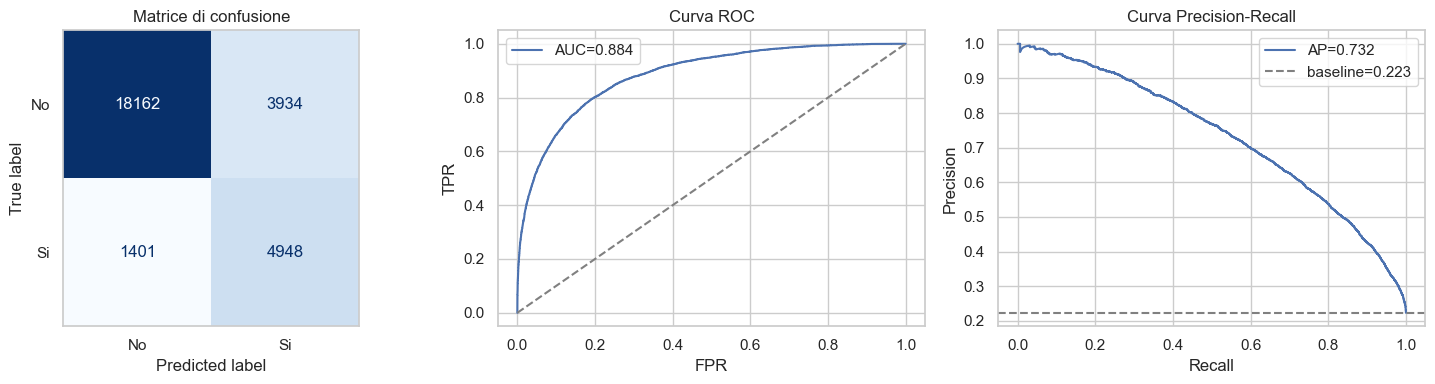

In [56]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["No", "Si"]).plot(ax=ax[0], colorbar=False, cmap="Blues")
ax[0].grid(False)
ax[0].set_title("Matrice di confusione")

fpr, tpr, _ = roc_curve(y_test, proba_test)
ax[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, proba_test):.3f}")
ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title("Curva ROC"); ax[1].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
ax[2].plot(rec, prec, label=f"AP={average_precision_score(y_test, proba_test):.3f}")
ax[2].axhline(y_test.mean(), ls="--", color="gray", label=f"baseline={y_test.mean():.3f}")
ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision")
ax[2].set_title("Curva Precision-Recall"); ax[2].legend()

plt.tight_layout()
plt.show()

## Quantificazione del leakage temporale

Lo stesso modello,
con gli stessi iperparametri e la stessa soglia, viene valutato in due condizioni per valutare il leakage:

* **split casuale**,  in cui train e test si
  sovrappongono nel tempo;
* **split cronologico** — quello adottato nel notebook.

I due test set non sono lo stesso insieme di giornate, quindi il confronto non è controllato in senso stretto, ma è esattamente ciò che si vuole mostrare. Noteremo che la procedura sbagliata produce sistematicamente numeri migliori di quelli che il modello otterrebbe sul campo.

In [57]:
def valuta_split(Xtr, Xte, ytr, yte, etichetta):
    modello = clone(best_model)
    if hasattr(modello.named_steps["clf"], "scale_pos_weight"):
        modello.named_steps["clf"].set_params(
            scale_pos_weight=float((ytr == 0).sum() / (ytr == 1).sum()))
    modello.fit(Xtr, ytr)
    p = proba_of(modello, Xte)
    pred = (p >= best_t).astype(int)
    return {"split":    etichetta,
            "F1":       f1_score(yte, pred),
            "ROC-AUC":  roc_auc_score(yte, p),
            "PR-AUC":   average_precision_score(yte, p),
            "recall":   recall_score(yte, pred),
            "costo/1k": cost_per_1000(yte, pred)}

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X, y, test_size=TEST_FRACTION, stratify=y, random_state=RANDOM_STATE)

confronto = pd.DataFrame([
    valuta_split(Xr_tr, Xr_te, yr_tr, yr_te, "casuale (con leakage)"),
    valuta_split(X_train, X_test, y_train, y_test, "cronologico (corretto)"),
]).set_index("split").round(4)

print(confronto.to_string())
d_f1  = confronto.loc["casuale (con leakage)", "F1"]      - confronto.loc["cronologico (corretto)", "F1"]
d_auc = confronto.loc["casuale (con leakage)", "ROC-AUC"] - confronto.loc["cronologico (corretto)", "ROC-AUC"]
print(f"\nSovrastima attribuibile al leakage temporale: "
      f"F1 {d_f1:+.4f}, ROC-AUC {d_auc:+.4f}")

                            F1  ROC-AUC  PR-AUC  recall  costo/1k
split                                                            
casuale (con leakage)   0.5566   0.8932  0.7540  0.9340  363.1281
cronologico (corretto)  0.5454   0.8825  0.7305  0.9274  377.4301

Sovrastima attribuibile al leakage temporale: F1 +0.0112, ROC-AUC +0.0107


## Importanza delle feature

Si usa la **permutation importance sul test set**, calcolata sulle colonne originali prima del
one-hot. Ogni variabile categorica riceve così un unico punteggio complessivo invece di
disperdersi su decine di dummy. L'importanza nativa per *gain* degli alberi è infatti distorta a
favore delle variabili con molte categorie, e su questo dataset `Location` ne ha 49.

La metrica è `average_precision` (PR-AUC), indipendente dalla soglia. Usare F1 misurerebbe il
modello al suo `predict` di default a 0.50, cioè un modello diverso da quello valutato nella
sezione di valutazione sul test set.

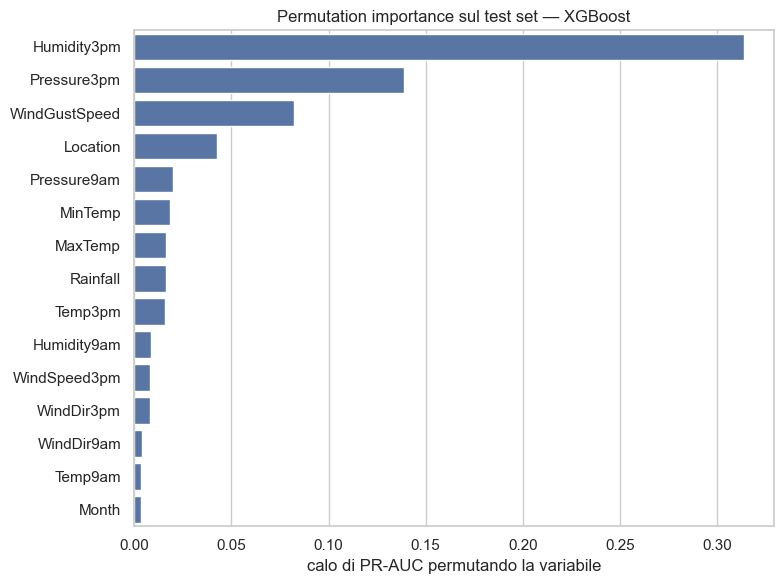

,feature,importanza,std
0,Humidity3pm,0.3136,0.0030
1,Pressure3pm,0.1387,0.0024
2,WindGustSpeed,0.0824,0.0020
3,Location,0.0428,0.0014
4,Pressure9am,0.0199,0.0009
5,MinTemp,0.0182,0.0006
6,MaxTemp,0.0164,0.0010
7,Rainfall,0.0162,0.0014
8,Temp3pm,0.0157,0.0018
9,Humidity9am,0.0088,0.0004


In [58]:
perm = permutation_importance(best_model, X_test, y_test, scoring="average_precision",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)

imp = (pd.DataFrame({"feature": X_test.columns,
                     "importanza": perm.importances_mean,
                     "std": perm.importances_std})
         .sort_values("importanza", ascending=False))

plt.figure(figsize=(8, 6))
sns.barplot(data=imp.head(15), x="importanza", y="feature", color="#4C72B0")
plt.title(f"Permutation importance sul test set — {best_name}")
plt.xlabel("calo di PR-AUC permutando la variabile"); plt.ylabel("")
plt.tight_layout(); plt.show()

display(imp.round(4).reset_index(drop=True))

## Inferenza su giorni concreti

In [59]:
rng = np.random.default_rng(RANDOM_STATE)
pos = np.sort(rng.choice(len(X_test), 8, replace=False))   # posizioni, non etichette di indice

cols_demo = [c for c in ["Location", "Humidity3pm", "Pressure3pm", "Sunshine", "RainfallLog"]
             if c in X_test.columns]

demo = X_test.iloc[pos][cols_demo].copy()
demo.insert(0, "Data", dates_test.iloc[pos].dt.date.values)
demo["P(pioggia)"] = proba_test[pos].round(3)
demo["Previsione"] = np.where(demo["P(pioggia)"] >= best_t, "Pioggia", "No")
demo["Reale"]      = np.where(y_test.iloc[pos].values == 1, "Pioggia", "No")
demo["Esito"]      = np.where(demo["Previsione"] == demo["Reale"], "OK", "errore")
demo.reset_index(drop=True)

,Data,Location,Humidity3pm,Pressure3pm,P(pioggia),Previsione,Reale,Esito
0,2015-12-31,MountGambier,14.0,1010.0,0.024,No,No,OK
1,2016-01-02,MountGinini,64.0,NaN,0.151,No,No,OK
2,2016-07-24,SalmonGums,68.0,NaN,0.113,No,No,OK
3,2016-07-28,Brisbane,38.0,1021.5,0.009,No,No,OK
4,2016-12-02,Canberra,22.0,1009.8,0.033,No,No,OK
5,2016-12-28,SalmonGums,36.0,NaN,0.164,No,No,OK
6,2017-02-12,Katherine,NaN,1003.2,0.424,Pioggia,Pioggia,OK
7,2017-04-03,Penrith,82.0,NaN,0.887,Pioggia,Pioggia,OK


In [ ]:
import json, os

NOME_CONFIG = "Baseline"   
FILE_LOG = "ablation.json"

riga = {
    "config":      NOME_CONFIG,
    "sparse_drop": SPARSE_DROP,
    "ridondanti":  REDUNDANT_DROP,
    "n_feature":   len(nomi),
    "CV_PRAUC_media": round(cv_results[best_name], 4),
    "CV_PRAUC_std":   round(cv_std[best_name], 4),
    "modello":     best_name,
    "soglia":      round(float(best_t), 3),
    "soglia_std":  round(soglia_std, 3), 
    "test_F1":     round(f1_score(y_test, y_pred), 4),
    "test_ROCAUC": round(roc_auc_score(y_test, proba_test), 4),
    "test_PRAUC":  round(average_precision_score(y_test, proba_test), 4),
    "test_recall": round(recall_score(y_test, y_pred), 4),
    "costo_1k":    round(cost_per_1000(y_test, y_pred), 1),
}

log = json.load(open(FILE_LOG)) if os.path.exists(FILE_LOG) else []
log = [r for r in log if r["config"] != NOME_CONFIG] + [riga]   # sovrascrive la stessa config
json.dump(log, open(FILE_LOG, "w"), indent=1)

pd.DataFrame(log).set_index("config")[
    ["n_feature", "CV_PRAUC_media", "CV_PRAUC_std","soglia", "soglia_std", "test_F1", "test_ROCAUC", "test_PRAUC", "costo_1k"]]

,n_feature,CV_PRAUC_media,CV_PRAUC_std,soglia,soglia_std,test_F1,test_ROCAUC,test_PRAUC,costo_1k
config,,,,,,,,,
E - riparametrizzazione anti-collinearita,133,0.7414,0.0114,0.20,0.010,0.6433,0.8864,0.7370,285.6
Recupero variabili correlate + rimozione ridondanze,137,0.7374,0.0123,0.20,0.012,0.6421,0.8850,0.7334,285.8
Baseline,135,0.7311,0.0116,0.23,0.022,0.6497,0.8840,0.7325,286.1
